<a href="https://colab.research.google.com/github/AshishRaj04/backpropagation-and-neural-network-implementation-from-scratch/blob/main/backpropagation_and_neural_network_implementation_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value():
  def __init__(self , data , _children=() , _op = "" , _label = ""):
    self.data = data
    self._prev = set(_children) # stores the previous two operands
    self.grad = 0 # Default the gradient is zero
    self._op = _op # stores the last operator
    self._label = _label
  def __repr__(self):
    return f"Value(data={self.data})"
  def __add__(self,other):
    out = Value(self.data + other.data , (self , other) , "+")
    return out
  def __mul__(self,other):
    out = Value(self.data * other.data , (self , other) , "*")
    return out
  def __sub__(self , other):
    out = Value(self.data - other.data , (self , other) , "-")
    return out
  def __truediv__(self , other):
    out = Value(self.data / other.data , (self , other) , "/")
    return out
  def tanh(self):
    x = self.data
    t = math.exp(x) - math.exp(-x) / math.exp(x) + math.exp(-x)
    out = Value(t , (self , ) , "tanh")
    return out

In [3]:
a = Value(2 , _label = 'a')
b = Value(-3 , _label = 'b')
c = Value(10 , _label = 'c')
e = a*b ; e._label = 'e'
f = e - c ; f._label = 'f'
g = f + a ; g._label = 'g'
h = Value(-2 , _label='h')
I = g * h ; I._label = 'I'
I

Value(data=28)

In [4]:
I._prev , I._op

({Value(data=-14), Value(data=-2)}, '*')

In [5]:
dI_dI = 1
dI_dg = -2
dI_dh = -14
dI_df = -2
dI_db = -4
dI_dc = 2
dI_de = -2
dI_da = 4

I.grad = 1
g.grad = -2
h.grad = -14
f.grad = -2
b.grad = -4
c.grad = 2
e.grad = -2
a.grad = 4

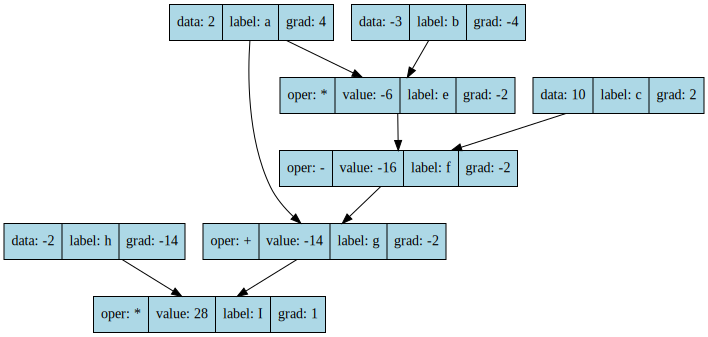

In [6]:
from graphviz import Digraph
from IPython.display import display

def draw_computation_graph(root):
    """Generates a Graphviz computation graph and displays it."""
    dot = Digraph(format='png', graph_attr={'rankdir': 'TB'})  # Top to Bottom layout

    def add_nodes_edges(node):
        """Recursive function to add nodes and edges."""
        if node not in visited:
            visited.add(node)
            node_id = str(id(node))

            # Node label with operation if applicable
            label = f"data: {node.data} |\n label: {node._label} | \n grad: {node.grad}"
            if node._op:
                label = f"oper: {node._op} | \n value: {node.data} | \n label: {node._label} | \n grad: {node.grad}"
            dot.node(node_id, label, shape="record", style="filled", fillcolor="lightblue")

            # Add edges for previous nodes
            for child in node._prev:
                child_id = str(id(child))
                dot.edge(child_id, node_id)
                add_nodes_edges(child)

    visited = set()
    add_nodes_edges(root)
    return dot


dot = draw_computation_graph(I)
display(dot)